🧬 1️⃣ Classification Dataset (Start Here – Easiest)
Promoter Detection Dataset

This is the most common DNABERT benchmark.

Task:
Binary classification
Is this sequence a promoter?

Good source:

EPDnew promoter dataset

Kaggle promoter dataset

UCSC promoter sequences

Simplest ready-to-use option:

🔹 UCI Promoter Gene Sequences Dataset

Contains:

57 bp sequences

Binary labels

Already formatted

Very small → good for testing pipeline.

🧬 2️⃣ Regression Dataset

Best beginner-friendly regression task:

TF Binding Affinity Prediction

Predict binding strength score.

Datasets:

DeepSEA dataset

ENCODE ChIP-seq binding data

DREAM TF binding challenge data

Simpler option:

🔹 Synthetic regression dataset

For first validation:
You can generate synthetic DNA and assign continuous scores.

Then later move to real TF binding dataset


🧬 3️⃣ MLM Dataset (Pretraining Task)

For MLM, you do NOT need labels.

You just need:

Large DNA sequences.

Best sources:

🔹 Human Genome FASTA

From:

UCSC Genome Browser

NCBI Genome

But full genome is huge.

Better option:

🔹 Sample chromosome fragment

Download:

chr22 FASTA file

Extract random 200–500bp chunks

MLM needs raw sequences only.

### Experiment-1 Masked Language modeling test (MLM) on Dnabert

Task is to detect promoter in the DNA Sequences..

We have 4 Nitrogenoues bases that makes of genetic codes - A T C G (Adenin, Thymine Cytosine and Guanine)

A pairs with T - A-T
C pairs with G = C-G sequence

![dna.png](attachment:"D:\gsoc26\deepchem\deepchem\feat\dataset\dna.png")

What is a promoter?

So I know DNA contains the blueprint for how to make a cell and rna and to be specific it's RNA Polymerase is the constructor that reads this and makes it but the RNA needs to know where exactly to start the reading procedure which is what the promoter will signal out.

Formal definition is:

A promoter is a specific DNA Sequence that tells RNA Polymerase on where to start the transcription here.
And then there is smtg called terminator which is the opposite of promoter.

So in this experiment we'll find whether a sequence is a promoter or not..



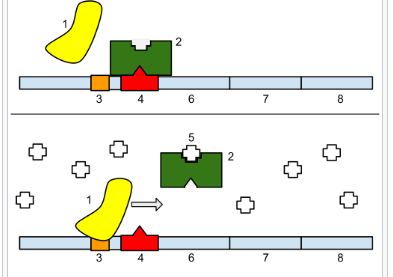

https://en.wikipedia.org/wiki/Promoter_(genetics)

Promoters can be about 100–1000 base pairs long, the sequence of which is highly dependent on the gene and product of transcription, type or class of RNA polymerase recruited to the site, and species of organism

2 is the regressor that prevents the RNA Polymerase onto the promoter

Simple Analogy

Think of:

Promoter = doorway

RNA polymerase = worker entering doorway

Operator = the spot where a guard can stand

Repressor = the guard

If the guard stands on the operator:

Worker cannot enter.

How will model find out whether a sequence is a promoter or not from just 4 letter? A T C G?

-   Promoter contains specific patterns called motifs

Two famous motifs:

-35 box: TTGACA

-10 box (TATA box): TATAAT

These occur at specific positions upstream of genes.

In [9]:
import pandas as pd
# prom_df=pd.read_csv("deepchem/feat/dataset/promoter.csv")
# nonprom_df=pd.read_csv("deepchem/feat/dataset/non_promoter.csv")
prom_df = pd.read_csv(r"D:\gsoc26\deepchem\deepchem\feat\dataset\promoter.csv")
nonprom_df = pd.read_csv(r"D:\gsoc26\deepchem\deepchem\feat\dataset\non_promoter.csv")

print("Promoters:",prom_df.shape)
print("Non Promoters:",nonprom_df.shape)

print("Example Promoter:")
print(prom_df.iloc[0,0])
print("Example Non Promoter:")
print(nonprom_df.iloc[0,0])

Promoters: (30000, 1)
Non Promoters: (30000, 1)
Example Promoter:
CTGTCCAATCATAAGCCTCACGTGACCTGCCGCGTAGGGAGGGCACGAACAGAAAGGTGCTGCGCATGCGTATTGAAAAACCTCACCTACTCTCGCGGGTCCTCAGCGTTCTCCTGCGGAACCTTTGAACGGGGTACTCGAGCCCACAGGGGAAGAGCAGCGGAAGGGGCCTTTCGGAACGATTTGGAACGAAAGGAAGTGGAAGAAACGCGGAACCATGGCCGCTGTGGTTGCTGTTTGCGGTGGTCTAGGGAGGAAGAAGTTGACACACTTGGTAACGGCTGCTGTCAGCCTTACACAT
Example Non Promoter:
ATCTCTAGCTCCTATACCACCACCACCACCATTACAGCGCCTCCCTCCAGGGTCCTGCAGAATGGAGGAGATAAGTTGGAGACGATGCCCCTCTACTTGGAAGACGACATTCGCCCTGATATAAAAGATGATATATATGACCCCACCTACAAGGATAAGGAAGGCCCAAGCCCCAAGGTTGAATATGTCTGGAGAAACATCATCCTTATGTCTCTGCTACACTTGGGAGCCCTGTATGGGATCACTTTGAT


In [10]:
import numpy as np
import deepchem as dc

# Extract sequences
prom_seqs = prom_df.iloc[:,0].str.upper().values
nonprom_seqs = nonprom_df.iloc[:,0].str.upper().values

# Labels
prom_labels = np.ones(len(prom_seqs))
nonprom_labels = np.zeros(len(nonprom_seqs))

# Combine
sequences = np.concatenate([prom_seqs, nonprom_seqs])
labels = np.concatenate([prom_labels, nonprom_labels])

print("Total samples:", len(sequences))


Total samples: 60000


In [11]:
dataset = dc.data.NumpyDataset(X=sequences, y=labels)

splitter = dc.splits.RandomSplitter()
train, valid, test = splitter.train_valid_test_split(dataset)


In [15]:
from deepchem.models.torch_models.dnabert import DNABERTModel
model = DNABERTModel(
    task="classification",
    model_name="zhihan1996/DNA_bert_6",
    n_tasks=1,
    learning_rate=5e-5
)
for param in model.model.bert.parameters():
    param.requires_grad=False
model.fit(train, nb_epoch=3)


d:\gsoc26\playground\dc_env\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at zhihan1996/DNA_bert_6 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


0.6946258544921875

In [ ]:
from deepchem.metrics import Metric, roc_auc_score

metric = Metric(roc_auc_score)
  
print("Train:", model.evaluate(train, [metric]))
print("Valid:", model.evaluate(valid, [metric]))
print("Test:", model.evaluate(test, [metric]))


Train: {'roc_auc_score': 0.5}
Valid: {'roc_auc_score': 0.5}
Test: {'roc_auc_score': 0.5}


In [20]:
print(labels.shape)
print(sequences[:5])
# import torch

preds = model.predict(test)
print(preds[:5])
print(np.unique(preds, axis=0))


(60000,)
['CTGTCCAATCATAAGCCTCACGTGACCTGCCGCGTAGGGAGGGCACGAACAGAAAGGTGCTGCGCATGCGTATTGAAAAACCTCACCTACTCTCGCGGGTCCTCAGCGTTCTCCTGCGGAACCTTTGAACGGGGTACTCGAGCCCACAGGGGAAGAGCAGCGGAAGGGGCCTTTCGGAACGATTTGGAACGAAAGGAAGTGGAAGAAACGCGGAACCATGGCCGCTGTGGTTGCTGTTTGCGGTGGTCTAGGGAGGAAGAAGTTGACACACTTGGTAACGGCTGCTGTCAGCCTTACACAT'
 'CCTTATTATACCTGTAAACTATTCTCTTCCTTTGTTACTTGCTTTTTATTCCCCTCACACTGGGCTTTTAGTAAGCTCCATGAGGTCAGGGGCCATTTGTTAGCGCCTATAAATACTGTGGAATCACTCAAACCCTAGGGCCGGTGGCACCAGGAAGTACTGGATAAGGAACCGCAACACTAACTAACTGGGGCTCAGTGCTCTCTTCCGCCTTCAGTGCCCTGCTCATCAAGGGTCTGGGTGAGGCCCCAGGTCATAAGGAAGCCCTCGCTCGACTGCCCCGGGGCCCATCGCAGCCCCC'
 'TTTGCCACACTGCAGCATTAGGATGGGACTTCTCTTCCTGTTCCTGGGAAGAATTAGAGATGTAACCCAAAGGTCACTATTTTTCTGAGATAAGGATCCCATAGGAGGAGAGAGCAATGAGTACATGGCCAGAGATCAAAGTGATAAGGGTTGGGCCAGAAGCCACAGTGCATAAAGCTTCAGACTTGCCACAGGAAATGAGGTGAGAAGTACGTCCACTCTTCTGTCCAGCTTTTAACAATCTAACTAATGGTTAGAGATTTTTCATTTTCTTTCAGCTACTCCTGCAGTGGTGGGGACA'
 'ACAAATAACAAAGATAGTTTTAGTAGATTATATCTGGGCTGTAGTGACCCAATTATCTGGTCAAAGGGCTGCAT

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNA_bert_6")

# Case A: Raw String
print(tokenizer.tokenize("ATGCATGC")) 
# Likely Output: ['[UNK]'] or ['ATGCAT', '##GC']

# Case B: Pre-split K-mers (What the model expects)
print(tokenizer.tokenize("ATGCAT TGCAAT GCATGC"))
# Likely Output: ['ATGCAT', 'TGCAAT', 'GCATGC']